# NCAA March Madness 2026 - Kaggle Competition

**Pipeline**: Feature Engineering 鈫 Model Training 鈫 Ensemble 鈫 Calibration 鈫 Submission

**Metric**: Brier Score (MSE of predicted probabilities)

---

## 0. Setup & Imports

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
import sys
from pathlib import Path

# ML
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Project paths
PROJECT_DIR = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
DATA_DIR = PROJECT_DIR / 'march-machine-learning-mania-2026'
sys.path.insert(0, str(PROJECT_DIR))

print(f'Project: {PROJECT_DIR}')
print(f'Data:    {DATA_DIR}')
print(f'Files:   {len(list(DATA_DIR.glob("*.csv")))} CSV files')

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

Project: d:\uiuc\Z kaggle\NCAA marchmadness2026
Data:    d:\uiuc\Z kaggle\NCAA marchmadness2026\march-machine-learning-mania-2026
Files:   35 CSV files


## 1. Feature Engineering Pipeline

Runs the complete feature pipeline:
1. Basic season stats (win rate, margins, momentum)
2. Advanced stats (Four Factors, efficiency, tempo)
3. Strength of Schedule
4. Elo ratings (3 variants)
5. Massey Ordinals rankings (men only)
6. Contextual (coach, conference, seed)

In [29]:
from src.pipeline import run_feature_pipeline

matchup_df, feature_cols, team_features = run_feature_pipeline(
    target='train', use_massey=True
)

print(f'\nMatchup shape: {matchup_df.shape}')
print(f'Feature cols:  {len(feature_cols)}')
print(f'Seasons:       {matchup_df.Season.min()}-{matchup_df.Season.max()}')
print(f'Label mean:    {matchup_df.Label.mean():.3f}')

LOADING DATA
Loaded 35 files: ['Cities', 'Conferences', 'MConferenceTourneyGames', 'MGameCities', 'MMasseyOrdinals', 'MNCAATourneyCompactResults', 'MNCAATourneyDetailedResults', 'MNCAATourneySeedRoundSlots', 'MNCAATourneySeeds', 'MNCAATourneySlots', 'MRegularSeasonCompactResults', 'MRegularSeasonDetailedResults', 'MSeasons', 'MSecondaryTourneyCompactResults', 'MSecondaryTourneyTeams', 'MTeamCoaches', 'MTeamConferences', 'MTeamSpellings', 'MTeams', 'SampleSubmissionStage1', 'SampleSubmissionStage2', 'WConferenceTourneyGames', 'WGameCities', 'WNCAATourneyCompactResults', 'WNCAATourneyDetailedResults', 'WNCAATourneySeeds', 'WNCAATourneySlots', 'WRegularSeasonCompactResults', 'WRegularSeasonDetailedResults', 'WSeasons', 'WSecondaryTourneyCompactResults', 'WSecondaryTourneyTeams', 'WTeamConferences', 'WTeamSpellings', 'WTeams']

COMPUTING TEAM-SEASON FEATURES

[1/7] Basic season statistics...
  -> 14311 team-seasons, 30 cols

[2/7] Advanced basketball statistics...
  -> 63 features

[3/7] S

In [30]:
# Quick look at data
print('Missing values per feature (top 20):')
missing = matchup_df[feature_cols].isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(20))

print(f'\nGames per season:')
print(matchup_df.groupby('Season').size().to_string())

Missing values per feature (top 20):
diff_rank_BPI         2522
diff_rank_USA         2214
diff_rank_AP          2204
diff_rank_LOG         2115
diff_rank_SPR         2115
diff_rank_ARG         2057
diff_rank_KPK         1786
diff_rank_REW         1722
diff_rank_MAS         1658
diff_rank_RPI         1602
diff_rank_DOK         1594
diff_rank_SAG         1536
diff_rank_SEL         1533
diff_rank_RTH         1468
diff_rank_WOL         1468
diff_rank_std_top     1402
diff_rank_std_all     1402
diff_rank_max_all     1402
diff_num_systems      1402
diff_rank_mean_top    1402
dtype: int64

Games per season:
Season
2003    127
2004    127
2005    127
2006    127
2007    127
2008    127
2009    127
2010    127
2011    130
2012    130
2013    130
2014    130
2015    130
2016    130
2017    130
2018    130
2019    130
2021    129
2022    134
2023    134
2024    134
2025    134


In [31]:
# === 1.5 Regular Season Auxiliary Training Data ===
from src.pipeline import build_matchup_features_vectorized
from src.data_loader import load_all_data, load_regular_season_compact

TOURNEY_WEIGHT = 5.0

_data_aug = load_all_data()
_compact  = load_regular_season_compact(_data_aug)
_compact  = _compact[
    (_compact['Season'] >= 2003) & (_compact['Season'] != 2020)
].copy()

_compact['TeamA'] = _compact[['WTeamID', 'LTeamID']].min(axis=1)
_compact['TeamB'] = _compact[['WTeamID', 'LTeamID']].max(axis=1)
_compact['Label'] = (_compact['WTeamID'] == _compact['TeamA']).astype(int)
# ScoreDiff from TeamA perspective (positive = TeamA won)
_compact['ScoreDiff'] = np.where(
    _compact['WTeamID'] == _compact['TeamA'],
    _compact['WScore'] - _compact['LScore'],
    _compact['LScore'] - _compact['WScore']
)
rs_raw = _compact[['Season', 'TeamA', 'TeamB', 'Label', 'Gender', 'ScoreDiff']].reset_index(drop=True)

# build_matchup_features_vectorized expects RAW team-level column names
# (it will create diff_XXX internally); NOT the matchup-level feature_cols
raw_team_cols = [c for c in team_features.columns if c not in ['Season', 'TeamID', 'Gender']]
rs_feats = build_matchup_features_vectorized(rs_raw, team_features, raw_team_cols)

# The result has diff_XXX columns; add Label/Gender, then align to matchup_df columns.
# H2H and seed features are tournament-only 鈫 fill as NaN (imputed at train time).
rs_feats['Label']         = rs_raw['Label'].values
rs_feats['Gender']        = rs_raw['Gender'].values
rs_feats['ScoreDiff']     = rs_raw['ScoreDiff'].values
rs_feats['is_tourney']    = 0
rs_feats['sample_weight'] = 1.0

# Tag original tournament data
matchup_df['is_tourney']    = 1
matchup_df['sample_weight'] = TOURNEY_WEIGHT

# Combine 鈥 tournament rows stay first, regular season appended
matchup_df_aug = pd.concat(
    [matchup_df, rs_feats.reset_index(drop=True)], ignore_index=True
)

# Gender-split augmented subsets (training only; validation stays tournament-only)
matchup_m_aug = matchup_df_aug[matchup_df_aug['Gender'] == 'M'].copy()
matchup_w_aug = matchup_df_aug[matchup_df_aug['Gender'] == 'W'].copy()

n_tourney = int(matchup_df['is_tourney'].sum())
n_rs      = int((matchup_df_aug['is_tourney'] == 0).sum())
print(f'=== Auxiliary Training Data ===')
print(f'  Tournament  (weight={TOURNEY_WEIGHT:.0f}): {n_tourney:,}')
print(f'  Regular season (weight=1): {n_rs:,}  ({n_rs/n_tourney:.1f}x more samples)')
print(f'  Total augmented:           {len(matchup_df_aug):,}')
print(f'  Men: {len(matchup_m_aug):,}  |  Women: {len(matchup_w_aug):,}')
# === ScoreDiff direction diagnostic ===
for g in ['M', 'W']:
    _g = _compact[_compact['Gender'] == g]
    agree = ((_g['ScoreDiff'] > 0) == (_g['Label'] == 1)).mean()
    print(f"{g}: {len(_g):,} rows | ScoreDiff direction agreement with Label: {agree:.3f}")


Loaded 35 files: ['Cities', 'Conferences', 'MConferenceTourneyGames', 'MGameCities', 'MMasseyOrdinals', 'MNCAATourneyCompactResults', 'MNCAATourneyDetailedResults', 'MNCAATourneySeedRoundSlots', 'MNCAATourneySeeds', 'MNCAATourneySlots', 'MRegularSeasonCompactResults', 'MRegularSeasonDetailedResults', 'MSeasons', 'MSecondaryTourneyCompactResults', 'MSecondaryTourneyTeams', 'MTeamCoaches', 'MTeamConferences', 'MTeamSpellings', 'MTeams', 'SampleSubmissionStage1', 'SampleSubmissionStage2', 'WConferenceTourneyGames', 'WGameCities', 'WNCAATourneyCompactResults', 'WNCAATourneyDetailedResults', 'WNCAATourneySeeds', 'WNCAATourneySlots', 'WRegularSeasonCompactResults', 'WRegularSeasonDetailedResults', 'WSeasons', 'WSecondaryTourneyCompactResults', 'WSecondaryTourneyTeams', 'WTeamConferences', 'WTeamSpellings', 'WTeams']
=== Auxiliary Training Data ===
  Tournament  (weight=5): 2,851
  Regular season (weight=1): 234,238  (82.2x more samples)
  Total augmented:           237,089
  Men: 120,152  | 

## 2. EDA: Feature Distributions & Importance

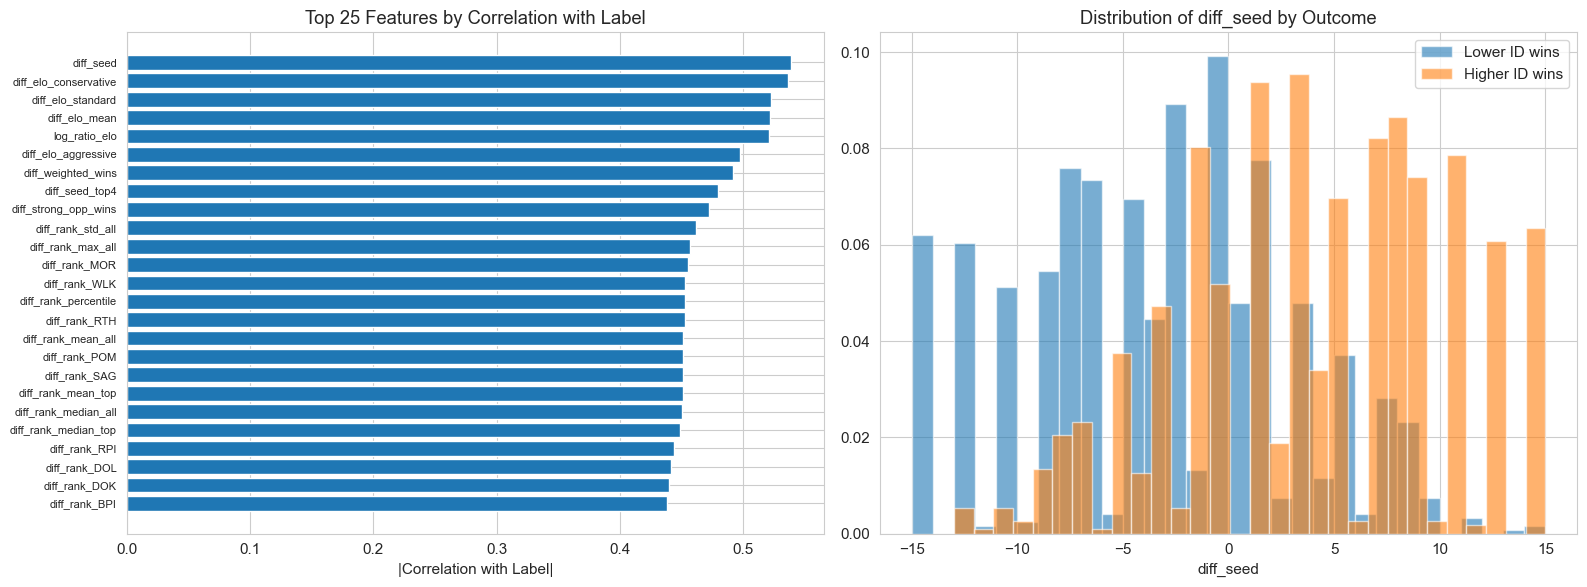

Top 15 correlated features:
diff_seed                0.538340
diff_elo_conservative    0.536350
diff_elo_standard        0.522587
diff_elo_mean            0.521830
log_ratio_elo            0.520619
diff_elo_aggressive      0.497013
diff_weighted_wins       0.491656
diff_seed_top4           0.479216
diff_strong_opp_wins     0.471767
diff_rank_std_all        0.461435
diff_rank_max_all        0.456883
diff_rank_MOR            0.455381
diff_rank_WLK            0.452618
diff_rank_percentile     0.452419
diff_rank_RTH            0.452298


In [32]:
# Top features correlation with Label
corr_with_label = matchup_df[feature_cols + ['Label']].corr()['Label'].drop('Label').abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top correlations
top_corr = corr_with_label.head(25)
axes[0].barh(range(len(top_corr)), top_corr.values)
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr.index, fontsize=8)
axes[0].set_xlabel('|Correlation with Label|')
axes[0].set_title('Top 25 Features by Correlation with Label')
axes[0].invert_yaxis()

# Distribution of key features by win/loss
key_feat = 'diff_seed'
if key_feat in matchup_df.columns:
    data_plot = matchup_df.dropna(subset=[key_feat])
    axes[1].hist(data_plot[data_plot.Label == 1][key_feat], bins=30, alpha=0.6, label='Lower ID wins', density=True)
    axes[1].hist(data_plot[data_plot.Label == 0][key_feat], bins=30, alpha=0.6, label='Higher ID wins', density=True)
    axes[1].set_xlabel(key_feat)
    axes[1].set_title(f'Distribution of {key_feat} by Outcome')
    axes[1].legend()

plt.tight_layout()
plt.show()

print('Top 15 correlated features:')
print(corr_with_label.head(15).to_string())

## 3. Cross-Validation Setup

**Time-Series CV**: Train on seasons < N, validate on season N's tournament.

In [33]:
VAL_SEASONS = [2019, 2021, 2022, 2023, 2024, 2025]  # skip 2020 (COVID)

def get_cv_folds(df, val_seasons=VAL_SEASONS):
    """Generate time-series CV folds."""
    folds = []
    for vs in val_seasons:
        train_idx = df[df['Season'] < vs].index.tolist()
        val_idx = df[df['Season'] == vs].index.tolist()
        if len(val_idx) > 0:
            folds.append((train_idx, val_idx))
    return folds

cv_folds = get_cv_folds(matchup_df)
print(f'{len(cv_folds)} CV folds:')
for i, (tr, va) in enumerate(cv_folds):
    vs = matchup_df.loc[va[0], 'Season']
    print(f'  Fold {i}: Train {len(tr)} games (up to {vs-1}), Val {len(va)} games (season {vs})')

6 CV folds:
  Fold 0: Train 2056 games (up to 2018), Val 130 games (season 2019)
  Fold 1: Train 2186 games (up to 2020), Val 129 games (season 2021)
  Fold 2: Train 2315 games (up to 2021), Val 134 games (season 2022)
  Fold 3: Train 2449 games (up to 2022), Val 134 games (season 2023)
  Fold 4: Train 2583 games (up to 2023), Val 134 games (season 2024)
  Fold 5: Train 2717 games (up to 2024), Val 134 games (season 2025)


In [34]:
def evaluate_cv(matchup_df, feature_cols, model_fn, clip=(0.02, 0.98), verbose=True):
    """
    Run time-series CV with any model function.
    model_fn(X_train, y_train, X_val, y_val) -> predictions on X_val
    Returns per-fold and overall Brier Score.
    """
    folds = get_cv_folds(matchup_df)
    results = []
    all_preds, all_labels, all_seasons = [], [], []
    oof_preds = np.full(len(matchup_df), np.nan)
    models = []

    for i, (train_idx, val_idx) in enumerate(folds):
        X_tr = matchup_df.loc[train_idx, feature_cols]
        y_tr = matchup_df.loc[train_idx, 'Label']
        X_va = matchup_df.loc[val_idx, feature_cols]
        y_va = matchup_df.loc[val_idx, 'Label']
        season = matchup_df.loc[val_idx[0], 'Season']

        pred, model = model_fn(X_tr, y_tr, X_va, y_va)
        pred = np.clip(pred, clip[0], clip[1])

        oof_preds[val_idx] = pred
        brier = brier_score_loss(y_va, pred)
        ll = log_loss(y_va, pred)
        results.append({'season': season, 'n': len(y_va), 'brier': brier, 'logloss': ll})
        all_preds.extend(pred.tolist())
        all_labels.extend(y_va.tolist())
        all_seasons.extend([season] * len(y_va))
        models.append(model)

        if verbose:
            print(f'  Fold {i} (Season {season}): Brier={brier:.4f}  LogLoss={ll:.4f}  n={len(y_va)}')

    overall_brier = brier_score_loss(all_labels, all_preds)
    overall_ll = log_loss(all_labels, all_preds)
    if verbose:
        print(f'  OVERALL: Brier={overall_brier:.4f}  LogLoss={overall_ll:.4f}  n={len(all_labels)}')

    return {
        'overall_brier': overall_brier,
        'overall_logloss': overall_ll,
        'per_fold': pd.DataFrame(results),
        'oof_preds': oof_preds,
        'models': models,
    }

## 4. Baselines

In [35]:
# Baseline 1: Seed-only historical lookup
print('=== Seed-Only Baseline ===')
folds = get_cv_folds(matchup_df)
seed_preds_all, seed_labels_all = [], []

for train_idx, val_idx in folds:
    train = matchup_df.loc[train_idx].dropna(subset=['diff_seed'])
    val = matchup_df.loc[val_idx].dropna(subset=['diff_seed'])
    seed_wr = train.groupby('diff_seed')['Label'].mean().to_dict()
    preds = val['diff_seed'].map(seed_wr).fillna(0.5).clip(0.02, 0.98)
    season = val.iloc[0]['Season']
    brier = brier_score_loss(val['Label'], preds)
    print(f'  Season {season}: Brier={brier:.4f}  n={len(val)}')
    seed_preds_all.extend(preds.tolist())
    seed_labels_all.extend(val['Label'].tolist())

seed_brier = brier_score_loss(seed_labels_all, seed_preds_all)
print(f'  OVERALL: Brier={seed_brier:.4f}')

=== Seed-Only Baseline ===
  Season 2019: Brier=0.1643  n=130
  Season 2021: Brier=0.1982  n=129
  Season 2022: Brier=0.1998  n=134
  Season 2023: Brier=0.1911  n=134
  Season 2024: Brier=0.1635  n=134
  Season 2025: Brier=0.1451  n=134
  OVERALL: Brier=0.1770


In [36]:
# Baseline 2: Logistic Regression with key features
print('=== Logistic Regression Baseline ===')

lr_key_feats = [c for c in feature_cols if any(
    k in c for k in ['diff_seed', 'diff_elo_standard', 'diff_win_rate',
                      'diff_net_efficiency_mean', 'diff_rank_mean_all']
)]
print(f'  Using {len(lr_key_feats)} features: {lr_key_feats}')

def lr_model(X_tr, y_tr, X_va, y_va):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr.fillna(0))
    X_va_s = scaler.transform(X_va.fillna(0))
    lr = LogisticRegression(C=1.0, max_iter=1000)
    lr.fit(X_tr_s, y_tr)
    return lr.predict_proba(X_va_s)[:, 1], (lr, scaler)

lr_results = evaluate_cv(matchup_df, lr_key_feats, lr_model)

=== Logistic Regression Baseline ===
  Using 7 features: ['diff_win_rate', 'diff_net_efficiency_mean', 'diff_elo_standard', 'diff_rank_mean_all', 'diff_seed', 'diff_seed_top4', 'diff_seed_top8']
  Fold 0 (Season 2019): Brier=0.1371  LogLoss=0.4196  n=130
  Fold 1 (Season 2021): Brier=0.1924  LogLoss=0.5575  n=129
  Fold 2 (Season 2022): Brier=0.1887  LogLoss=0.5529  n=134
  Fold 3 (Season 2023): Brier=0.1877  LogLoss=0.5492  n=134
  Fold 4 (Season 2024): Brier=0.1675  LogLoss=0.4950  n=134
  Fold 5 (Season 2025): Brier=0.1232  LogLoss=0.3942  n=134
  OVERALL: Brier=0.1661  LogLoss=0.4947  n=795


## 5. LightGBM Baseline Tuned

### 5.1 LightGBM Baseline

In [37]:
print('=== LightGBM Baseline (all features) ===')

def lgb_baseline(X_tr, y_tr, X_va, y_va):
    params = {
        'objective': 'binary', 'metric': 'binary_logloss',
        'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': 5,
        'min_child_samples': 30, 'feature_fraction': 0.8,
        'bagging_fraction': 0.8, 'bagging_freq': 5,
        'reg_alpha': 0.1, 'reg_lambda': 1.0,
        'verbose': -1, 'n_jobs': -1, 'seed': 42,
    }
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval = lgb.Dataset(X_va, label=y_va, reference=dtrain)
    model = lgb.train(params, dtrain, num_boost_round=1000,
                      valid_sets=[dval],
                      callbacks=[lgb.early_stopping(50, verbose=False)])
    return model.predict(X_va), model

lgb_base_results = evaluate_cv(matchup_df, feature_cols, lgb_baseline)

=== LightGBM Baseline (all features) ===
  Fold 0 (Season 2019): Brier=0.1519  LogLoss=0.4487  n=130
  Fold 1 (Season 2021): Brier=0.1901  LogLoss=0.5555  n=129
  Fold 2 (Season 2022): Brier=0.1767  LogLoss=0.5229  n=134
  Fold 3 (Season 2023): Brier=0.1921  LogLoss=0.5642  n=134
  Fold 4 (Season 2024): Brier=0.1740  LogLoss=0.5053  n=134
  Fold 5 (Season 2025): Brier=0.1340  LogLoss=0.4042  n=134
  OVERALL: Brier=0.1698  LogLoss=0.5000  n=795


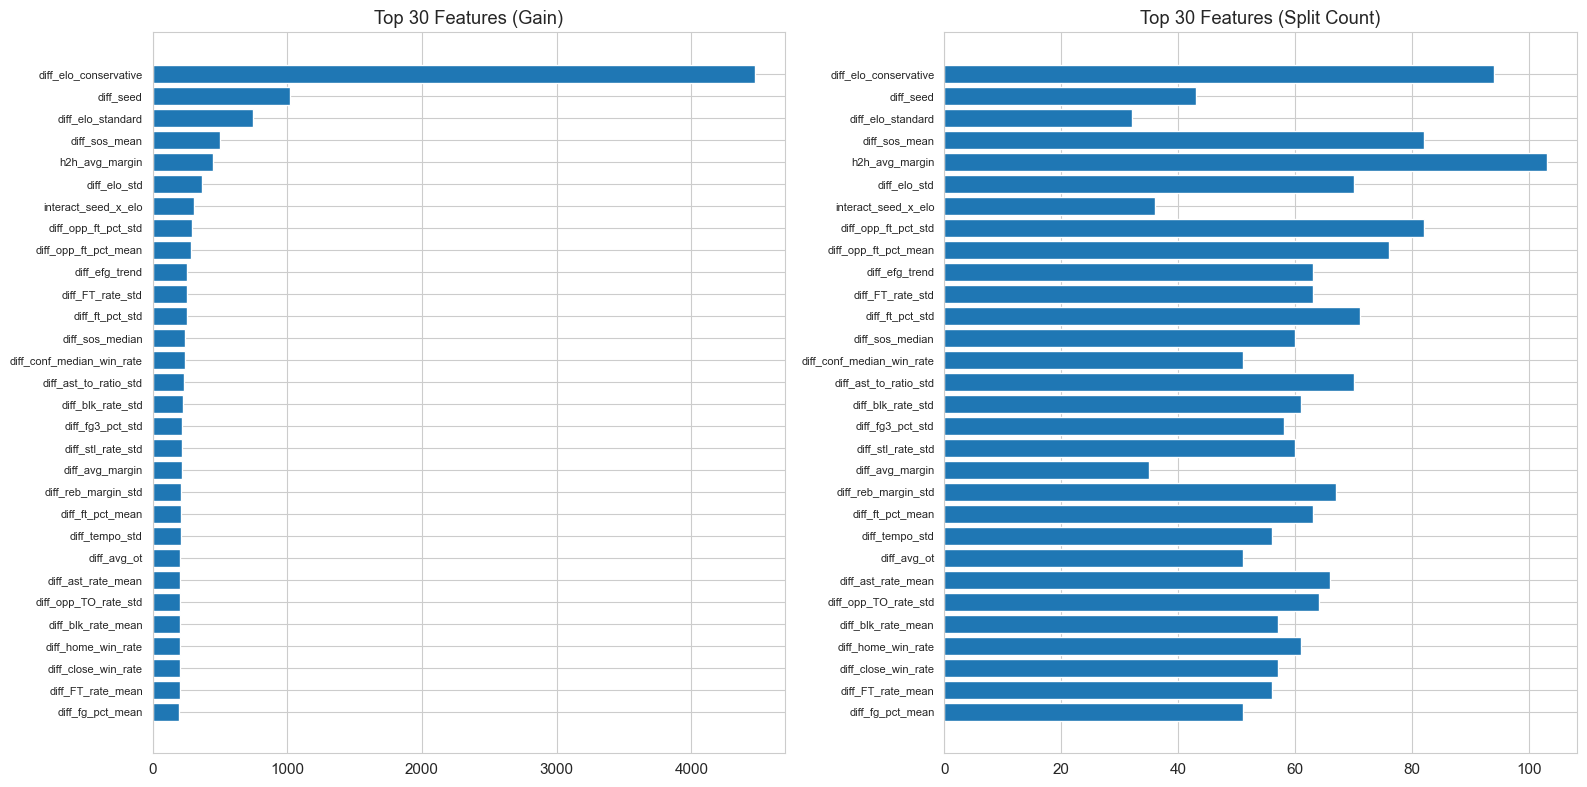

                  feature        gain  split
    diff_elo_conservative 4473.948387     94
                diff_seed 1021.038697     43
        diff_elo_standard  742.146450     32
            diff_sos_mean  497.415212     82
           h2h_avg_margin  445.782757    103
             diff_elo_std  366.146169     70
      interact_seed_x_elo  310.300132     36
      diff_opp_ft_pct_std  290.936011     82
     diff_opp_ft_pct_mean  288.028324     76
           diff_efg_trend  258.955015     63
         diff_FT_rate_std  257.047175     63
          diff_ft_pct_std  253.376691     71
          diff_sos_median  240.667569     60
diff_conf_median_win_rate  237.993510     51
    diff_ast_to_ratio_std  232.572708     70
        diff_blk_rate_std  223.196387     61
         diff_fg3_pct_std  220.734670     58
        diff_stl_rate_std  218.229063     60
          diff_avg_margin  214.817520     35
      diff_reb_margin_std  214.291365     67
         diff_ft_pct_mean  213.708160     63
          

In [38]:
# Feature importance from last fold
last_model = lgb_base_results['models'][-1]
fi = pd.DataFrame({
    'feature': feature_cols,
    'gain': last_model.feature_importance(importance_type='gain'),
    'split': last_model.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
top_n = 30
fi_top = fi.head(top_n)

axes[0].barh(range(top_n), fi_top['gain'].values)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(fi_top['feature'].values, fontsize=8)
axes[0].set_title(f'Top {top_n} Features (Gain)')
axes[0].invert_yaxis()

axes[1].barh(range(top_n), fi_top['split'].values)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(fi_top['feature'].values, fontsize=8)
axes[1].set_title(f'Top {top_n} Features (Split Count)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(fi.head(30).to_string(index=False))

### 5.2 Feature Selection -> Keep Top-K by Importance

In [39]:
# Select best K — exclude h2h features (unavailable in Stage2 -> train/inference distribution shift)
fi_sorted = fi.sort_values("gain", ascending=False).reset_index(drop=True)
fi_no_h2h = fi_sorted[~fi_sorted["feature"].str.startswith("h2h_")]
best_k = 19
selected_features = fi_no_h2h["feature"].head(best_k).tolist()
print(f"Feature set: Top-{best_k} (h2h excluded — zero info in Stage2)")
print(f"Selected features ({len(selected_features)}):")
for i, f in enumerate(selected_features):
    print(f"  {i+1:3d}. {f}")


Feature set: Top-19 (h2h excluded — zero info in Stage2)
Selected features (19):
    1. diff_elo_conservative
    2. diff_seed
    3. diff_elo_standard
    4. diff_sos_mean
    5. diff_elo_std
    6. interact_seed_x_elo
    7. diff_opp_ft_pct_std
    8. diff_opp_ft_pct_mean
    9. diff_efg_trend
   10. diff_FT_rate_std
   11. diff_ft_pct_std
   12. diff_sos_median
   13. diff_conf_median_win_rate
   14. diff_ast_to_ratio_std
   15. diff_blk_rate_std
   16. diff_fg3_pct_std
   17. diff_stl_rate_std
   18. diff_avg_margin
   19. diff_reb_margin_std


In [40]:
# === Feature Stability: keep features that appear in top-K across >= 4/6 folds ===
from collections import Counter
folds = get_cv_folds(matchup_df)
fold_top_features = []
K_PER_FOLD = 19  # match our feature count
for tr_idx, va_idx in folds:
    fill = matchup_df.loc[tr_idx, selected_features].median()
    X_tr = matchup_df.loc[tr_idx, selected_features].fillna(fill)
    y_tr = matchup_df.loc[tr_idx, "Label"]
    dtr = lgb.Dataset(X_tr, label=y_tr)
    _fi_params = {'objective': 'binary', 'metric': 'binary_logloss', 'verbose': -1,
                  'n_jobs': -1, 'seed': 42, 'num_leaves': 31}
    m = lgb.train(_fi_params, dtr, num_boost_round=500,
                  callbacks=[lgb.log_evaluation(-1)])
    fi_fold = dict(zip(selected_features, m.feature_importance("gain")))
    top_k = sorted(fi_fold, key=fi_fold.get, reverse=True)[:K_PER_FOLD]
    fold_top_features.append(set(top_k))

# Count how many folds each feature appears in top-K
feat_counts = Counter(f for s in fold_top_features for f in s)
MIN_FOLDS = 4  # must appear in >= 4/6 folds
stable_features = [f for f in selected_features if feat_counts.get(f, 0) >= MIN_FOLDS]
unstable = [f for f in selected_features if feat_counts.get(f, 0) < MIN_FOLDS]

print(f"Feature stability (top-{K_PER_FOLD} per fold, threshold >= {MIN_FOLDS}/6 folds):")
print(f"  Stable:   {len(stable_features)} features")
print(f"  Unstable: {len(unstable)} features -> removed")
if unstable:
    for f in unstable:
        print(f"    ✗ {f} (appeared in {feat_counts.get(f,0)}/6 folds)")
for f in stable_features:
    print(f"    ✓ {f} ({feat_counts.get(f,0)}/6 folds)")

# Update selected_features to stable-only
selected_features = stable_features
print(f"Final feature count: {len(selected_features)}")


Feature stability (top-19 per fold, threshold >= 4/6 folds):
  Stable:   19 features
  Unstable: 0 features -> removed
    ✓ diff_elo_conservative (6/6 folds)
    ✓ diff_seed (6/6 folds)
    ✓ diff_elo_standard (6/6 folds)
    ✓ diff_sos_mean (6/6 folds)
    ✓ diff_elo_std (6/6 folds)
    ✓ interact_seed_x_elo (6/6 folds)
    ✓ diff_opp_ft_pct_std (6/6 folds)
    ✓ diff_opp_ft_pct_mean (6/6 folds)
    ✓ diff_efg_trend (6/6 folds)
    ✓ diff_FT_rate_std (6/6 folds)
    ✓ diff_ft_pct_std (6/6 folds)
    ✓ diff_sos_median (6/6 folds)
    ✓ diff_conf_median_win_rate (6/6 folds)
    ✓ diff_ast_to_ratio_std (6/6 folds)
    ✓ diff_blk_rate_std (6/6 folds)
    ✓ diff_fg3_pct_std (6/6 folds)
    ✓ diff_stl_rate_std (6/6 folds)
    ✓ diff_avg_margin (6/6 folds)
    ✓ diff_reb_margin_std (6/6 folds)
Final feature count: 19


### 5.3 Hyperparameter Tuning (Optuna)

In [41]:
# === Experiment 0: Default LGB baseline (no tuning) ===
# Benchmark: if Optuna gain < 0.003, tuning is -- likely CV overfitting
_default_params = {
    'objective': 'binary', 'metric': 'binary_logloss',
    'verbose': -1, 'n_jobs': -1, 'seed': 42,
    'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': -1,
    'min_child_samples': 20, 'feature_fraction': 1.0, 'reg_lambda': 0.0,
}
_folds = get_cv_folds(matchup_df)
_p0, _l0 = [], []
for tr_idx, va_idx in _folds:
    fill = matchup_df.loc[tr_idx, selected_features].median()
    X_tr = matchup_df.loc[tr_idx, selected_features].fillna(fill)
    X_va = matchup_df.loc[va_idx, selected_features].fillna(fill)
    y_tr = matchup_df.loc[tr_idx, 'Label']
    y_va = matchup_df.loc[va_idx, 'Label']
    dtr = lgb.Dataset(X_tr, label=y_tr)
    dva = lgb.Dataset(X_va, label=y_va, reference=dtr)
    m = lgb.train(_default_params, dtr, num_boost_round=2000, valid_sets=[dva],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    _p0.extend(np.clip(m.predict(X_va), 0.02, 0.98).tolist())
    _l0.extend(y_va.tolist())
lgb_default_brier = brier_score_loss(_l0, _p0)
print(f'Experiment 0 -- Default LGB Brier: {lgb_default_brier:.4f}')

# === Experiment 1: Optuna-tuned LGB (5 params fixed, 100 trials) ===
# Fixed: learning_rate=0.05, bagging_fraction=0.8, bagging_freq=1, reg_alpha=0
# Tuned: num_leaves, max_depth, min_child_samples, feature_fraction, reg_lambda
def optuna_lgb_objective(trial):
    params = {
        'objective': 'binary', 'metric': 'binary_logloss',
        'verbose': -1, 'n_jobs': -1, 'seed': 42,
        'learning_rate':   0.05,
        'bagging_fraction': 0.8,
        'bagging_freq':     1,
        'reg_alpha':        0.0,
        'num_leaves':        trial.suggest_int('num_leaves', 4, 32),
        'max_depth':         trial.suggest_int('max_depth', 3, 5),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.4, 0.9),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.1, 5.0, log=True),
    }
    folds = get_cv_folds(matchup_df)
    all_preds, all_labels = [], []
    for tr_idx, va_idx in folds:
        fill = matchup_df.loc[tr_idx, selected_features].median()
        X_tr = matchup_df.loc[tr_idx, selected_features].fillna(fill)
        X_va = matchup_df.loc[va_idx, selected_features].fillna(fill)
        y_tr = matchup_df.loc[tr_idx, 'Label']
        y_va = matchup_df.loc[va_idx, 'Label']
        dtr = lgb.Dataset(X_tr, label=y_tr)
        dva = lgb.Dataset(X_va, label=y_va, reference=dtr)
        m = lgb.train(params, dtr, num_boost_round=2000, valid_sets=[dva],
                      callbacks=[lgb.early_stopping(50, verbose=False)])
        all_preds.extend(np.clip(m.predict(X_va), 0.02, 0.98).tolist())
        all_labels.extend(y_va.tolist())
    return brier_score_loss(all_labels, all_preds)

print('\nRunning Optuna (5 params, 100 trials, fixed seed=42)...')
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', study_name='lgb_tune', sampler=sampler)
study.optimize(optuna_lgb_objective, n_trials=100, show_progress_bar=True)

optuna_gain = lgb_default_brier - study.best_value
print(f'\nExp 0 (default): {lgb_default_brier:.4f}')
print(f'Exp 1 (Optuna):  {study.best_value:.4f}  (gain = {optuna_gain:+.4f})')
if optuna_gain < 0.003:
    print(' Optuna gain < 0.003  -- likely CV overfitting; consider using default params')
else:
    print('  Optuna gain is meaningful')

best_lgb_params = {
    'objective': 'binary', 'metric': 'binary_logloss',
    'verbose': -1, 'n_jobs': -1, 'seed': 42,
    'learning_rate': 0.05, 'bagging_fraction': 0.8, 'bagging_freq': 1, 'reg_alpha': 0.0,
    **study.best_params
}
print(f'\nFinal LGB params: {best_lgb_params}')

Experiment 0 -- Default LGB Brier: 0.1682

Running Optuna (5 params, 100 trials, fixed seed=42)...


  0%|          | 0/100 [00:00<?, ?it/s]


Exp 0 (default): 0.1682
Exp 1 (Optuna):  0.1646  (gain = +0.0037)
  Optuna gain is meaningful

Final LGB params: {'objective': 'binary', 'metric': 'binary_logloss', 'verbose': -1, 'n_jobs': -1, 'seed': 42, 'learning_rate': 0.05, 'bagging_fraction': 0.8, 'bagging_freq': 1, 'reg_alpha': 0.0, 'num_leaves': 5, 'max_depth': 4, 'min_child_samples': 70, 'feature_fraction': 0.47962205769490296, 'reg_lambda': 0.12615461686507326}


In [42]:
# Evaluate tuned LightGBM (uses best_lgb_params from Optuna cell above)

def lgb_tuned(X_tr, y_tr, X_va, y_va):
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval = lgb.Dataset(X_va, label=y_va, reference=dtrain)
    model = lgb.train(best_lgb_params, dtrain, num_boost_round=2000,
                      valid_sets=[dval],
                      callbacks=[lgb.early_stopping(50, verbose=False)])
    return model.predict(X_va), model

print('=== Tuned LightGBM ===')
lgb_tuned_results = evaluate_cv(matchup_df, selected_features, lgb_tuned)

=== Tuned LightGBM ===
  Fold 0 (Season 2019): Brier=0.1487  LogLoss=0.4429  n=130
  Fold 1 (Season 2021): Brier=0.1891  LogLoss=0.5530  n=129
  Fold 2 (Season 2022): Brier=0.1801  LogLoss=0.5338  n=134
  Fold 3 (Season 2023): Brier=0.1915  LogLoss=0.5601  n=134
  Fold 4 (Season 2024): Brier=0.1654  LogLoss=0.4891  n=134
  Fold 5 (Season 2025): Brier=0.1258  LogLoss=0.4007  n=134
  OVERALL: Brier=0.1667  LogLoss=0.4965  n=795


## 9. Model Comparison

In [43]:
model_scores = {
    'Naive (0.5)':        0.25,
    'Seed-only':          seed_brier,
    'LR (key feats)':     lr_results['overall_brier'],
    'LGB baseline':       lgb_base_results['overall_brier'],
    'LGB default (Exp0)': lgb_default_brier,
    'LGB tuned (Exp1)':   lgb_tuned_results['overall_brier'],
}

scores_df = pd.DataFrame(list(model_scores.items()), columns=['Model', 'Brier'])
scores_df = scores_df.sort_values('Brier').reset_index(drop=True)
print(scores_df.to_string(index=False))
print('\n(Gender-specific ensemble results shown in Final Summary after Section 9.5)')

             Model    Brier
    LR (key feats) 0.166059
  LGB tuned (Exp1) 0.166724
LGB default (Exp0) 0.168241
      LGB baseline 0.169765
         Seed-only 0.176950
       Naive (0.5) 0.250000

(Gender-specific ensemble results shown in Final Summary after Section 9.5)


## 9.5 Gender-Specific Models

Train **separate LGB (multi-seed) + CatBoost** models for men and women.

Key insight: Women lack Massey Ordinals data -> a unified model forces ~50% NaN imputation

In [44]:
# === 9.5.1 Gender split + per-gender feature selection ===
matchup_m = matchup_df[matchup_df['Gender'] == 'M'].copy()
matchup_w = matchup_df[matchup_df['Gender'] == 'W'].copy()
print(f'Men: {len(matchup_m)} games | Women: {len(matchup_w)} games')

# Drop features that are >50% NaN within each gender's data
m_miss = matchup_m[selected_features].isnull().mean()
w_miss = matchup_w[selected_features].isnull().mean()
selected_features_m = [f for f in selected_features if m_miss[f] < 0.5]
selected_features_w = [f for f in selected_features if w_miss[f] < 0.5]
dropped_for_w = sorted(set(selected_features_m) - set(selected_features_w))
print(f'Men features:   {len(selected_features_m)}')
print(f'Women features: {len(selected_features_w)} ({len(dropped_for_w)} dropped, mostly Massey/men-only)')
if dropped_for_w:
    print(f'  e.g. {dropped_for_w[:6]}')

Men: 1449 games | Women: 1402 games
Men features:   19
Women features: 19 (0 dropped, mostly Massey/men-only)


In [45]:
# === 9.5.2 Gender-specific CV runner (LGB multi-seed + CatBoost) ===
LGB_SEEDS = [42, 43, 44]  # 3 seeds for variance reduction

def evaluate_cv_gender(matchup_sub, feature_cols, model_fn, clip=(0.02, 0.98)):
    folds = get_cv_folds(matchup_sub)
    all_preds, all_labels = [], []
    oof_full = np.full(len(matchup_df), np.nan)
    models = []
    for tr_idx, va_idx in folds:
        fill = matchup_sub.loc[tr_idx, feature_cols].median()
        X_tr = matchup_sub.loc[tr_idx, feature_cols].fillna(fill)
        X_va = matchup_sub.loc[va_idx, feature_cols].fillna(fill)
        y_tr = matchup_sub.loc[tr_idx, 'Label']
        y_va = matchup_sub.loc[va_idx, 'Label']
        pred, model = model_fn(X_tr, y_tr, X_va, y_va)
        pred = np.clip(pred, *clip)
        oof_full[va_idx] = pred
        all_preds.extend(pred.tolist())
        all_labels.extend(y_va.tolist())
        models.append(model)
    brier = brier_score_loss(all_labels, all_preds)
    return {'overall_brier': brier, 'oof_preds': oof_full, 'models': models}


def lgb_multiseed_fn(X_tr, y_tr, X_va, y_va):
    """Train LGB with multiple seeds, return averaged predictions."""
    preds = []
    seed_models = []
    for seed in LGB_SEEDS:
        params = dict(best_lgb_params)
        params['seed'] = seed
        dtr = lgb.Dataset(X_tr, label=y_tr)
        dva = lgb.Dataset(X_va, label=y_va, reference=dtr)
        m = lgb.train(params, dtr, num_boost_round=2000, valid_sets=[dva],
                      callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        preds.append(m.predict(X_va))
        seed_models.append(m)
    return np.mean(preds, axis=0), seed_models  # returns list of models


def catboost_model(X_tr, y_tr, X_va, y_va):
    model = cb.CatBoostClassifier(
        iterations=1000, learning_rate=0.05, depth=4,
        l2_leaf_reg=3.0, subsample=0.8, verbose=0, random_seed=42,
        eval_metric='Logloss', early_stopping_rounds=50,
    )
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=False)
    return model.predict_proba(X_va)[:, 1], model


print('=== Gender-Specific CV (LGB x3 seeds + CatBoost) ===')
print('--- Men ---')
lgb_m = evaluate_cv_gender(matchup_m, selected_features_m, lgb_multiseed_fn)
cb_m  = evaluate_cv_gender(matchup_m, selected_features_m, catboost_model)

print('--- Women ---')
lgb_w = evaluate_cv_gender(matchup_w, selected_features_w, lgb_multiseed_fn)
cb_w  = evaluate_cv_gender(matchup_w, selected_features_w, catboost_model)

print(f'{"Model":<16} {"Men":>8} {"Women":>8}')
for nm, rm, rw in [('LGB (3 seeds)', lgb_m, lgb_w), ('CatBoost', cb_m, cb_w)]:
    print(f'{nm:<16} {rm["overall_brier"]:>8.4f} {rw["overall_brier"]:>8.4f}')

# OOF correlation
val_m = ~np.isnan(lgb_m['oof_preds'])
corr_m = np.corrcoef(lgb_m['oof_preds'][val_m], cb_m['oof_preds'][val_m])[0, 1]
val_w = ~np.isnan(lgb_w['oof_preds'])
corr_w = np.corrcoef(lgb_w['oof_preds'][val_w], cb_w['oof_preds'][val_w])[0, 1]
print(f'LGB–CB OOF correlation:  Men={corr_m:.3f}  Women={corr_w:.3f}')


=== Gender-Specific CV (LGB x3 seeds + CatBoost) ===
--- Men ---
--- Women ---
Model                 Men    Women
LGB (3 seeds)      0.1891   0.1386
CatBoost           0.1874   0.1361
LGB–CB OOF correlation:  Men=0.966  Women=0.987


In [46]:
# === 9.5.2b  Augmented CV (TOURNEY_WEIGHT=5.0, Men only, LGB multi-seed + CB) ===
# Women: aug consistently hurts -> skip.

def lgb_multiseed_sw(X_tr, y_tr, X_va, y_va, sample_weight=None):
    """Multi-seed LGB with sample weights."""
    sw = sample_weight.values if hasattr(sample_weight, 'values') else sample_weight
    preds = []
    seed_models = []
    for seed in LGB_SEEDS:
        params = dict(best_lgb_params)
        params['seed'] = seed
        dtr = lgb.Dataset(X_tr, label=y_tr, weight=sw)
        dva = lgb.Dataset(X_va, label=y_va, reference=dtr)
        m = lgb.train(params, dtr, num_boost_round=2000, valid_sets=[dva],
                      callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        preds.append(m.predict(X_va))
        seed_models.append(m)
    return np.mean(preds, axis=0), seed_models

def catboost_model_sw(X_tr, y_tr, X_va, y_va, sample_weight=None):
    sw = sample_weight.values if hasattr(sample_weight, 'values') else sample_weight
    model = cb.CatBoostClassifier(
        iterations=1000, learning_rate=0.05, depth=4, l2_leaf_reg=3.0,
        subsample=0.8, verbose=0, random_seed=42,
        eval_metric='Logloss', early_stopping_rounds=50,
    )
    model.fit(X_tr, y_tr, sample_weight=sw, eval_set=(X_va, y_va), verbose=False)
    return model.predict_proba(X_va)[:, 1], model

def evaluate_cv_gender_aug(matchup_sub, feature_cols, model_fn_sw,
                            clip=(0.02, 0.98), train_aug=None):
    folds = get_cv_folds(matchup_sub)
    all_preds, all_labels = [], []
    oof_full = np.full(len(matchup_df), np.nan)
    models = []
    for tr_idx, va_idx in folds:
        val_season = matchup_sub.loc[va_idx[0], 'Season']
        fill = matchup_sub.loc[tr_idx, feature_cols].median()
        tr_data = train_aug[train_aug['Season'] < val_season] if train_aug is not None                   else matchup_sub.loc[tr_idx]
        X_tr = tr_data[feature_cols].fillna(fill)
        y_tr = tr_data['Label']
        sw   = tr_data['sample_weight'] if 'sample_weight' in tr_data.columns else None
        X_va = matchup_sub.loc[va_idx, feature_cols].fillna(fill)
        y_va = matchup_sub.loc[va_idx, 'Label']
        pred, model = model_fn_sw(X_tr, y_tr, X_va, y_va, sample_weight=sw)
        pred = np.clip(pred, *clip)
        oof_full[va_idx] = pred
        all_preds.extend(pred.tolist())
        all_labels.extend(y_va.tolist())
        models.append(model)
    brier = brier_score_loss(all_labels, all_preds)
    return {'overall_brier': brier, 'oof_preds': oof_full, 'models': models}

# matchup_m_aug already created in cell 1.5 with correct weights
print(f'=== Augmented CV — Men only (TOURNEY_WEIGHT={TOURNEY_WEIGHT}) ===')
lgb_m_aug = evaluate_cv_gender_aug(matchup_m, selected_features_m, lgb_multiseed_sw, train_aug=matchup_m_aug)
cb_m_aug  = evaluate_cv_gender_aug(matchup_m, selected_features_m, catboost_model_sw, train_aug=matchup_m_aug)

print(f'{"Model":<16} {"M-orig":>8} {"M-aug":>8}  Δ')
for nm, ro, ra in [('LGB (3 seeds)', lgb_m, lgb_m_aug), ('CatBoost', cb_m, cb_m_aug)]:
    d = ra['overall_brier'] - ro['overall_brier']
    print(f'{nm:<16} {ro["overall_brier"]:>8.4f} {ra["overall_brier"]:>8.4f} ({d:+.4f})')

# Auto-select: use aug if better, orig otherwise
lgb_m = lgb_m_aug if lgb_m_aug['overall_brier'] < lgb_m['overall_brier'] else lgb_m
cb_m  = cb_m_aug  if cb_m_aug['overall_brier']  < cb_m['overall_brier']  else cb_m

print('=== Women: skipping augmented CV (aug hurts -> using orig) ===')


=== Augmented CV — Men only (TOURNEY_WEIGHT=5.0) ===
Model              M-orig    M-aug  Δ
LGB (3 seeds)      0.1891   0.1875 (-0.0016)
CatBoost           0.1874   0.1872 (-0.0002)
=== Women: skipping augmented CV (aug hurts -> using orig) ===


In [47]:
# === 9.5.3 Gender-specific ensemble: Exp1 (LGB-only) vs Exp2 (LGB+CB equal-weight) ===
from scipy.optimize import minimize

val_mask_m = (~np.isnan(lgb_m['oof_preds'])) & (matchup_df['Gender'] == 'M').values
val_mask_w = (~np.isnan(lgb_w['oof_preds'])) & (matchup_df['Gender'] == 'W').values
y_m = matchup_df.loc[val_mask_m, 'Label'].values
y_w = matchup_df.loc[val_mask_w, 'Label'].values

# -- Experiment 1: LGB only --
lgb_only_brier_m = lgb_m['overall_brier']
lgb_only_brier_w = lgb_w['overall_brier']
oof_lgb_only = np.full(len(matchup_df), np.nan)
oof_lgb_only[val_mask_m] = lgb_m['oof_preds'][val_mask_m]
oof_lgb_only[val_mask_w] = lgb_w['oof_preds'][val_mask_w]
val_mask_gender = val_mask_m | val_mask_w
exp1_brier = brier_score_loss(
    matchup_df.loc[val_mask_gender, 'Label'].values,
    np.clip(oof_lgb_only[val_mask_gender], 0.02, 0.98)
)

# -- Experiment 2: LGB + CB equal-weight (0 free parameters) --
oof_lgbcb = np.full(len(matchup_df), np.nan)
oof_lgbcb[val_mask_m] = 0.5 * lgb_m['oof_preds'][val_mask_m] + 0.5 * cb_m['oof_preds'][val_mask_m]
oof_lgbcb[val_mask_w] = 0.5 * lgb_w['oof_preds'][val_mask_w] + 0.5 * cb_w['oof_preds'][val_mask_w]
exp2_brier = brier_score_loss(
    matchup_df.loc[val_mask_gender, 'Label'].values,
    np.clip(oof_lgbcb[val_mask_gender], 0.02, 0.98)
)
exp2_m = brier_score_loss(y_m, np.clip(oof_lgbcb[val_mask_m], 0.02, 0.98))
exp2_w = brier_score_loss(y_w, np.clip(oof_lgbcb[val_mask_w], 0.02, 0.98))

print('=== Ensemble Experiments ===')
print(f'Exp 1 -- LGB only:        {exp1_brier:.4f}')
print(f'Exp 2 -- LGB+CB equal:    {exp2_brier:.4f}  '
      f'(delta vs Exp1 = {exp1_brier - exp2_brier:+.4f})')
print(f'  Men:   {exp2_m:.4f}  Women: {exp2_w:.4f}')

delta = exp1_brier - exp2_brier
if delta > 0.001:
    print('  CB adds meaningful value -- using LGB+CB equal-weight')
elif delta > 0:
    print('  CB marginal gain (< 0.001) -- within noise, but using LGB+CB')
else:
    print('  CB hurts -- using LGB only')

# -- Pick best & expose as canonical variables --
if exp2_brier <= exp1_brier:
    oof_gender_ensemble  = oof_lgbcb
    gender_ensemble_brier = exp2_brier
    _ensemble_name = 'LGB+CB equal-weight'
    opt_weights_m = np.array([0.5, 0.5])
    opt_weights_w = np.array([0.5, 0.5])
    _base_models = ['LGB', 'CB']
else:
    oof_gender_ensemble  = oof_lgb_only
    gender_ensemble_brier = exp1_brier
    _ensemble_name = 'LGB only'
    opt_weights_m = np.array([1.0])
    opt_weights_w = np.array([1.0])
    _base_models = ['LGB']

print(f'\nUsing: {_ensemble_name}  ->  Brier = {gender_ensemble_brier:.4f}')


=== Ensemble Experiments ===
Exp 1 -- LGB only:        0.1633
Exp 2 -- LGB+CB equal:    0.1620  (delta vs Exp1 = +0.0012)
  Men:   0.1870  Women: 0.1366
  CB adds meaningful value -- using LGB+CB equal-weight

Using: LGB+CB equal-weight  ->  Brier = 0.1620


In [48]:
# === Spread Regression + Isotonic (Men only) -- Correlation Evaluation ===
from sklearn.isotonic import IsotonicRegression
import xgboost as xgb

def spread_isotonic_cv(matchup_sub, feature_cols):
    folds = get_cv_folds(matchup_sub)
    oof_preds = np.full(len(matchup_df), np.nan)
    all_preds, all_labels = [], []
    for tr_idx, va_idx in folds:
        fill = matchup_sub.loc[tr_idx, feature_cols].median()
        X_tr = matchup_sub.loc[tr_idx, feature_cols].fillna(fill)
        X_va = matchup_sub.loc[va_idx, feature_cols].fillna(fill)
        y_tr_label = matchup_sub.loc[tr_idx, 'Label']
        y_va_label = matchup_sub.loc[va_idx, 'Label']
        if 'ScoreDiff' in matchup_sub.columns:
            y_tr_spread = matchup_sub.loc[tr_idx, 'ScoreDiff']
        else:
            y_tr_spread = (y_tr_label * 2 - 1) * 10
        dtrain = xgb.DMatrix(X_tr, label=y_tr_spread)
        dval = xgb.DMatrix(X_va)
        xgb_params = {
            'objective': 'reg:pseudohubererror', 'max_depth': 3,
            'learning_rate': 0.05, 'subsample': 0.8,
            'colsample_bytree': 0.7, 'seed': 42, 'verbosity': 0,
        }
        xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=500,
                              evals=[(dtrain, 'train')], verbose_eval=False)
        spread_pred_tr = xgb_model.predict(dtrain)
        spread_pred_va = xgb_model.predict(dval)
        iso = IsotonicRegression(y_min=0.02, y_max=0.98, out_of_bounds='clip')
        iso.fit(spread_pred_tr, y_tr_label.values)
        prob_va = iso.predict(spread_pred_va)
        oof_preds[va_idx] = prob_va
        all_preds.extend(prob_va.tolist())
        all_labels.extend(y_va_label.tolist())
    brier = brier_score_loss(all_labels, all_preds)
    return {'overall_brier': brier, 'oof_preds': oof_preds}

print('=== Spread-Isotonic Evaluation (Men only, tournament data) ===')
spread_m = spread_isotonic_cv(matchup_m, selected_features_m)
print(f'Spread-Isotonic Brier (men): {spread_m["overall_brier"]:.4f}')
print(f'LGB Brier (men):             {lgb_m["overall_brier"]:.4f}')
val_m_mask = ~np.isnan(lgb_m['oof_preds']) & ~np.isnan(spread_m['oof_preds'])
corr_spread_lgb = np.corrcoef(lgb_m['oof_preds'][val_m_mask], spread_m['oof_preds'][val_m_mask])[0, 1]
print(f'\nSpread-LGB OOF correlation (men): {corr_spread_lgb:.3f}')
if corr_spread_lgb < 0.90:
    print(f'  Correlation < 0.90 -- Spread adds diverse signal, worth including')
    USE_SPREAD = True
else:
    print(f'  Correlation >= 0.90 -- Spread too similar to LGB, skipping')
    USE_SPREAD = False


=== Spread-Isotonic Evaluation (Men only, tournament data) ===
Spread-Isotonic Brier (men): 0.2229
LGB Brier (men):             0.1875

Spread-LGB OOF correlation (men): 0.843
  Correlation < 0.90 -- Spread adds diverse signal, worth including


In [49]:
# === Set calibration inputs from gender-specific ensemble ===
val_mask  = val_mask_gender
y_val_all = matchup_df.loc[val_mask, 'Label'].values
best_oof  = np.clip(oof_gender_ensemble[val_mask], 0.02, 0.98)
best_name = 'gender_weighted'

print(f'Calibration base: {_ensemble_name}  Brier = {gender_ensemble_brier:.4f}')
print(f'Val samples: {len(y_val_all)}  (M={val_mask_m.sum()}  W={val_mask_w.sum()})')


Calibration base: LGB+CB equal-weight  Brier = 0.1620
Val samples: 795  (M=401  W=394)


## 11. Probability Calibration

### 11.1 Calibration Diagnostics

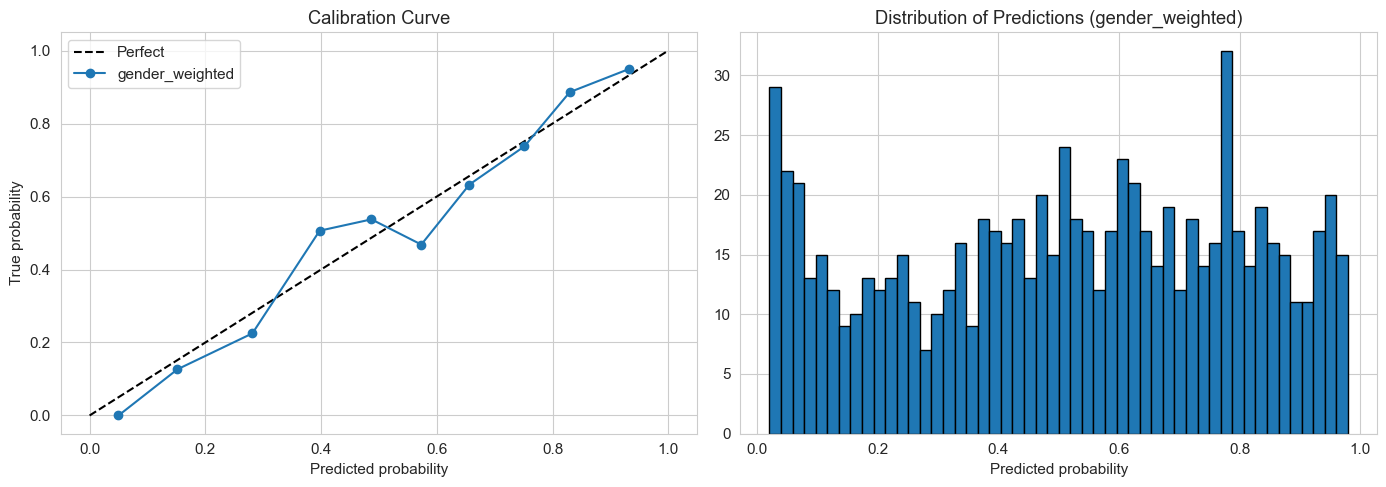

Expected Calibration Error (ECE): 0.0506


In [50]:
# Calibration plot for best ensemble
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_val_all, best_oof, n_bins=10, strategy='quantile')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect')
axes[0].plot(prob_pred, prob_true, 'o-', label=f'{best_name}')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('True probability')
axes[0].set_title('Calibration Curve')
axes[0].legend()
axes[1].hist(best_oof, bins=50, edgecolor='black')
axes[1].set_title(f'Distribution of Predictions ({best_name})')
axes[1].set_xlabel('Predicted probability')
plt.tight_layout()
plt.show()
ece = np.mean(np.abs(prob_true - prob_pred))
print(f'Expected Calibration Error (ECE): {ece:.4f}')


### 11.2 Temperature Scaling

In [51]:
from scipy.special import logit, expit

def temperature_scale(preds, labels, temps=np.arange(0.5, 2.01, 0.05)):
    logits = logit(np.clip(preds, 0.001, 0.999))
    best_t, best_brier = 1.0, brier_score_loss(labels, preds)
    for t in temps:
        calibrated = np.clip(expit(logits / t), 0.02, 0.98)
        b = brier_score_loss(labels, calibrated)
        if b < best_brier:
            best_brier = b
            best_t = t
    return best_t, best_brier

print('=== Temperature Scaling ===')
print(f'Before calibration: Brier = {brier_score_loss(y_val_all, best_oof):.4f}')
best_temp, best_brier = temperature_scale(best_oof, y_val_all)
print(f'Optimal temperature: {best_temp:.2f}')
print(f'After temperature:   Brier = {best_brier:.4f}')


=== Temperature Scaling ===
Before calibration: Brier = 0.1620
Optimal temperature: 0.95
After temperature:   Brier = 0.1619


## 12. Final Summary

In [52]:
from scipy.special import logit, expit

final_brier = best_brier
calibrated_final = np.clip(
    expit(logit(np.clip(best_oof, 0.001, 0.999)) / best_temp),
    0.02, 0.98)

print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
all_scores = {
    'Naive (0.5)':        0.25,
    'Seed-only':          seed_brier,
    'LR (key feats)':     lr_results['overall_brier'],
    'LGB baseline':       lgb_base_results['overall_brier'],
    'LGB default (Exp0)': lgb_default_brier,
    'LGB tuned (Exp1)':   lgb_tuned_results['overall_brier'],
    'LGB+CB (Exp2)':      gender_ensemble_brier,
    '+ Temp Scaling':     best_brier,
}
for name, score in all_scores.items():
    marker = ' <-- BEST' if score == min(all_scores.values()) else ''
    print(f'  {name:28s}: Brier = {score:.4f}{marker}')

print(f'\nOptuna gain (Exp0->Exp1): {lgb_default_brier - lgb_tuned_results["overall_brier"]:+.4f}')
print(f'CB gain    (Exp1->Exp2):  {lgb_tuned_results["overall_brier"] - gender_ensemble_brier:+.4f}')
print(f'Improvement over naive:  {(0.25 - final_brier) / 0.25 * 100:.1f}%')
print(f'Improvement over seeds:  {(seed_brier - final_brier) / seed_brier * 100:.1f}%')

print('\n--- Per-Gender Breakdown ---')
if 'Gender' in matchup_df.columns:
    m_mask_val = val_mask & (matchup_df['Gender'] == 'M').values
    w_mask_val = val_mask & (matchup_df['Gender'] == 'W').values
    for gender_mask, lbl in [(m_mask_val, 'Men'), (w_mask_val, 'Women')]:
        sub = gender_mask[val_mask]
        if sub.sum() > 0:
            g_b = brier_score_loss(y_val_all[sub], calibrated_final[sub])
            print(f'  {lbl}: Brier = {g_b:.4f}  (n={sub.sum()})')


FINAL RESULTS SUMMARY
  Naive (0.5)                 : Brier = 0.2500
  Seed-only                   : Brier = 0.1770
  LR (key feats)              : Brier = 0.1661
  LGB baseline                : Brier = 0.1698
  LGB default (Exp0)          : Brier = 0.1682
  LGB tuned (Exp1)            : Brier = 0.1667
  LGB+CB (Exp2)               : Brier = 0.1620
  + Temp Scaling              : Brier = 0.1619 <-- BEST

Optuna gain (Exp0->Exp1): +0.0015
CB gain    (Exp1->Exp2):  +0.0047
Improvement over naive:  35.2%
Improvement over seeds:  8.5%

--- Per-Gender Breakdown ---
  Men: Brier = 0.1869  (n=401)
  Women: Brier = 0.1365  (n=394)


## 13. Generate Submission

### 13.1 Train final models on all available data

In [53]:
# === 13.1 Train gender-specific final models on ALL training data ===
# LGB: 3 seeds averaged | CatBoost: single seed
print('=== Training Gender-Specific Final Models ===')

m_fill = matchup_m[selected_features_m].median()
w_fill = matchup_w[selected_features_w].median()

# Men: augmented data (tourney + RS, TOURNEY_WEIGHT=5)
X_m_all  = matchup_m_aug[selected_features_m].fillna(m_fill)
y_m_all  = matchup_m_aug['Label']
sw_m_all = matchup_m_aug['sample_weight'].values

# Women: tournament-only (aug hurts women)
X_w_all  = matchup_w[selected_features_w].fillna(w_fill)
y_w_all  = matchup_w['Label']

def _median_iters(models_list):
    iters = []
    for m in models_list:
        if isinstance(m, list):
            iters.extend([mm.best_iteration for mm in m])
        else:
            iters.append(m.best_iteration)
    return int(np.median(iters))

# Men LGB (3 seeds)
print('  Men LGB (3 seeds)...')
n_rounds_lgb_m = _median_iters(lgb_m['models'])
final_lgb_m_list = []
for seed in LGB_SEEDS:
    params = dict(best_lgb_params)
    params['seed'] = seed
    m = lgb.train(params, lgb.Dataset(X_m_all, label=y_m_all, weight=sw_m_all),
                  num_boost_round=n_rounds_lgb_m)
    final_lgb_m_list.append(m)

# Men CB
print('  Men CatBoost...')
final_cb_m = cb.CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=4,
    l2_leaf_reg=3.0, subsample=0.8, verbose=0, random_seed=42,
)
final_cb_m.fit(X_m_all, y_m_all, sample_weight=sw_m_all, verbose=0)

# Women LGB (3 seeds)
print('  Women LGB (3 seeds)...')
n_rounds_lgb_w = _median_iters(lgb_w['models'])
final_lgb_w_list = []
for seed in LGB_SEEDS:
    params = dict(best_lgb_params)
    params['seed'] = seed
    m = lgb.train(params, lgb.Dataset(X_w_all, label=y_w_all),
                  num_boost_round=n_rounds_lgb_w)
    final_lgb_w_list.append(m)

# Women CB
print('  Women CatBoost...')
final_cb_w = cb.CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=4,
    l2_leaf_reg=3.0, subsample=0.8, verbose=0, random_seed=42,
)
final_cb_w.fit(X_w_all, y_w_all, verbose=0)

print(f'\nFinal models: LGB x{len(LGB_SEEDS)} seeds + CB (Men & Women)')
print(f'  Men LGB rounds: {n_rounds_lgb_m} | Women LGB rounds: {n_rounds_lgb_w}')


=== Training Gender-Specific Final Models ===
  Men LGB (3 seeds)...
  Men CatBoost...
  Women LGB (3 seeds)...
  Women CatBoost...

Final models: LGB x3 seeds + CB (Men & Women)
  Men LGB rounds: 102 | Women LGB rounds: 75


In [54]:
# === predict_with_ensemble: gender-specific (LGB multi-seed + CB) prediction ===

def _get_X(df_sub, feat_cols, fill):
    missing = [c for c in feat_cols if c not in df_sub.columns]
    if missing:
        df_sub = df_sub.copy()
        for c in missing:
            df_sub[c] = fill.get(c, 0) if hasattr(fill, 'get') else 0
    return df_sub[feat_cols].fillna(fill)

def predict_with_stacking(df, feat_cols_m, feat_cols_w, m_fill, w_fill):
    is_mens = (df['TeamA'] < 2000).values
    n = len(df)
    ensemble = np.full(n, np.nan)
    if is_mens.sum() > 0:
        X_m = _get_X(df[is_mens], feat_cols_m, m_fill)
        p_lgb = np.mean([m.predict(X_m) for m in final_lgb_m_list], axis=0)
        p_cb  = final_cb_m.predict_proba(X_m)[:, 1]
        if len(opt_weights_m) == 2:
            ensemble[is_mens] = opt_weights_m[0] * p_lgb + opt_weights_m[1] * p_cb
        else:
            ensemble[is_mens] = p_lgb
    if (~is_mens).sum() > 0:
        X_w = _get_X(df[~is_mens], feat_cols_w, w_fill)
        p_lgb = np.mean([m.predict(X_w) for m in final_lgb_w_list], axis=0)
        p_cb  = final_cb_w.predict_proba(X_w)[:, 1]
        if len(opt_weights_w) == 2:
            ensemble[~is_mens] = opt_weights_w[0] * p_lgb + opt_weights_w[1] * p_cb
        else:
            ensemble[~is_mens] = p_lgb
    return np.clip(ensemble, 0.02, 0.98)

print(f'predict_with_stacking defined -- {_ensemble_name} x{len(LGB_SEEDS)} seeds (Men & Women)')


predict_with_stacking defined -- LGB+CB equal-weight x3 seeds (Men & Women)


In [55]:
# === 13.2 Stage1 Validation (Backtest 2022-2025) ===
from src.data_loader import load_all_data, load_tourney_compact, build_tourney_labels

print('Building Stage1 features (all 2022-2025 matchups)...')
stage1_df, _, _ = run_feature_pipeline(target='stage1', use_massey=True)

preds_s1 = predict_with_stacking(stage1_df, selected_features_m, selected_features_w,
                                  m_fill, w_fill)
preds_s1_final = np.clip(
    expit(logit(np.clip(preds_s1, 0.001, 0.999)) / best_temp),
    0.02, 0.98)

import os
os.makedirs('submissions/stage1', exist_ok=True)
sub_s1 = stage1_df[['ID']].copy()
sub_s1['Pred'] = preds_s1_final
sub_s1.to_csv('submissions/stage1/submission_ensemble_v1.csv', index=False)
print(f'Stage1 submission saved: {os.path.abspath("submissions/stage1/submission_ensemble_v1.csv")}  ({len(sub_s1)} rows)')

labels_s1 = build_tourney_labels(load_tourney_compact(load_all_data()))
merged = sub_s1.merge(labels_s1, on='ID', how='inner')
if len(merged) > 0:
    from sklearn.metrics import brier_score_loss
    s1_brier = brier_score_loss(merged['Label'], merged['Pred'])
    print(f'\nSanity-check Brier (optimistic, {len(merged)} games): {s1_brier:.4f}')
    print(f'Unbiased CV estimate:                                    {final_brier:.4f}')
    print(f'\nPer season:')
    merged['Season'] = merged['ID'].str.split('_').str[0].astype(int)
    for s in sorted(merged['Season'].unique()):
        ss = merged[merged['Season'] == s]
        print(f'  {s}: Brier={brier_score_loss(ss["Label"], ss["Pred"]):.4f}  n={len(ss)}')
    merged['is_mens'] = merged['ID'].apply(lambda x: int(x.split('_')[1]) < 2000)
    print(f'\nPer gender:')
    for g, lbl in [(True, 'Men'), (False, 'Women')]:
        gg = merged[merged['is_mens'] == g]
        if len(gg) > 0:
            print(f'  {lbl}: Brier={brier_score_loss(gg["Label"], gg["Pred"]):.4f}  n={len(gg)}')


Building Stage1 features (all 2022-2025 matchups)...
LOADING DATA
Loaded 35 files: ['Cities', 'Conferences', 'MConferenceTourneyGames', 'MGameCities', 'MMasseyOrdinals', 'MNCAATourneyCompactResults', 'MNCAATourneyDetailedResults', 'MNCAATourneySeedRoundSlots', 'MNCAATourneySeeds', 'MNCAATourneySlots', 'MRegularSeasonCompactResults', 'MRegularSeasonDetailedResults', 'MSeasons', 'MSecondaryTourneyCompactResults', 'MSecondaryTourneyTeams', 'MTeamCoaches', 'MTeamConferences', 'MTeamSpellings', 'MTeams', 'SampleSubmissionStage1', 'SampleSubmissionStage2', 'WConferenceTourneyGames', 'WGameCities', 'WNCAATourneyCompactResults', 'WNCAATourneyDetailedResults', 'WNCAATourneySeeds', 'WNCAATourneySlots', 'WRegularSeasonCompactResults', 'WRegularSeasonDetailedResults', 'WSeasons', 'WSecondaryTourneyCompactResults', 'WSecondaryTourneyTeams', 'WTeamConferences', 'WTeamSpellings', 'WTeams']

COMPUTING TEAM-SEASON FEATURES

[1/7] Basic season statistics...
  -> 14311 team-seasons, 30 cols

[2/7] Advanc

### 13.3 Generate Stage 2 Predictions

In [56]:
# Load Stage2 submission template and build features
print('Building Stage 2 features...')
stage2_df, _, _ = run_feature_pipeline(target='stage2', use_massey=True)

missing_m = [c for c in selected_features_m if c not in stage2_df.columns]
missing_w = [c for c in selected_features_w if c not in stage2_df.columns]
if missing_m or missing_w:
    print(f'Warning: {len(set(missing_m+missing_w))} features missing in stage2, filling with 0')
print(f'Stage 2 shape: ({len(stage2_df)}, {len(selected_features_m)})')


Building Stage 2 features...
LOADING DATA
Loaded 35 files: ['Cities', 'Conferences', 'MConferenceTourneyGames', 'MGameCities', 'MMasseyOrdinals', 'MNCAATourneyCompactResults', 'MNCAATourneyDetailedResults', 'MNCAATourneySeedRoundSlots', 'MNCAATourneySeeds', 'MNCAATourneySlots', 'MRegularSeasonCompactResults', 'MRegularSeasonDetailedResults', 'MSeasons', 'MSecondaryTourneyCompactResults', 'MSecondaryTourneyTeams', 'MTeamCoaches', 'MTeamConferences', 'MTeamSpellings', 'MTeams', 'SampleSubmissionStage1', 'SampleSubmissionStage2', 'WConferenceTourneyGames', 'WGameCities', 'WNCAATourneyCompactResults', 'WNCAATourneyDetailedResults', 'WNCAATourneySeeds', 'WNCAATourneySlots', 'WRegularSeasonCompactResults', 'WRegularSeasonDetailedResults', 'WSeasons', 'WSecondaryTourneyCompactResults', 'WSecondaryTourneyTeams', 'WTeamConferences', 'WTeamSpellings', 'WTeams']

COMPUTING TEAM-SEASON FEATURES

[1/7] Basic season statistics...
  -> 14311 team-seasons, 30 cols

[2/7] Advanced basketball statistics

Predicting Stage 2 with gender-specific models...
Method: gender_weighted
Predictions  mean=0.502  std=0.336  min=0.020  max=0.980


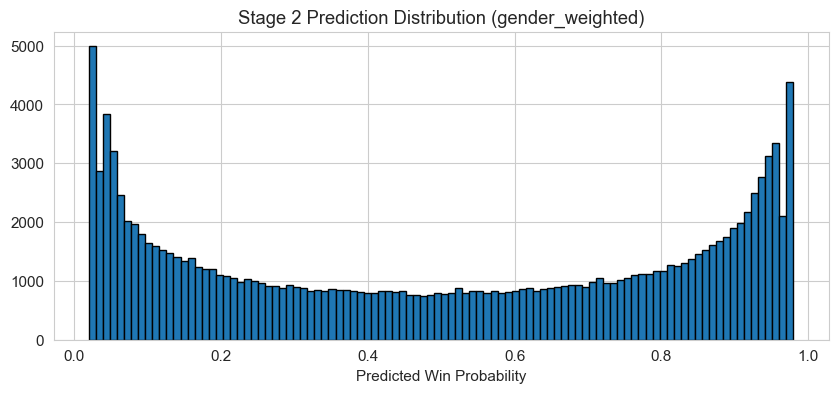

In [57]:
# === 13.3 Generate Stage 2 Predictions ===
print('Predicting Stage 2 with gender-specific models...')
ensemble_pred = predict_with_stacking(stage2_df, selected_features_m, selected_features_w,
                                       m_fill, w_fill)

ensemble_pred_final = np.clip(
    expit(logit(np.clip(ensemble_pred, 0.001, 0.999)) / best_temp),
    0.02, 0.98)

print(f'Method: {best_name}')
print(f'Predictions  mean={ensemble_pred_final.mean():.3f}  '
      f'std={ensemble_pred_final.std():.3f}  '
      f'min={ensemble_pred_final.min():.3f}  max={ensemble_pred_final.max():.3f}')

plt.figure(figsize=(10, 4))
plt.hist(ensemble_pred_final, bins=100, edgecolor='black')
plt.title(f'Stage 2 Prediction Distribution ({best_name})')
plt.xlabel('Predicted Win Probability')
plt.show()


In [58]:
# === Submission Sanity Checks ===
pred = ensemble_pred_final
is_mens = (stage2_df['TeamA'] < 2000).values

print('=== Prediction Distribution ===')
print(f'Overall:  mean={pred.mean():.3f}  std={pred.std():.3f}  min={pred.min():.3f}  max={pred.max():.3f}')
print(f'Men:      mean={pred[is_mens].mean():.3f}  std={pred[is_mens].std():.3f}')
print(f'Women:    mean={pred[~is_mens].mean():.3f}  std={pred[~is_mens].std():.3f}')
print(f'Extreme predictions:')
print(f'  pred < 0.10: {(pred < 0.10).mean():.1%}  ({(pred < 0.10).sum()} games)')
print(f'  pred > 0.90: {(pred > 0.90).mean():.1%}  ({(pred > 0.90).sum()} games)')
print(f'  0.4 < pred < 0.6 (near-50-50): {((pred > 0.4) & (pred < 0.6)).mean():.1%}')

# Symmetry check
print('=== Symmetry Check (sample 200 games) ===')
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(stage2_df), size=min(200, len(stage2_df)), replace=False)
s2_sample = stage2_df.iloc[sample_idx].copy().reset_index(drop=True)
diff_cols_m = [c for c in selected_features_m if c.startswith('diff_')]
diff_cols_w = [c for c in selected_features_w if c.startswith('diff_')]
s2_swap = s2_sample.copy()
s2_swap['TeamA'] = s2_sample['TeamB']
s2_swap['TeamB'] = s2_sample['TeamA']
for c in set(diff_cols_m + diff_cols_w):
    if c in s2_swap.columns:
        s2_swap[c] = -s2_swap[c]
pred_orig = predict_with_stacking(s2_sample, selected_features_m, selected_features_w, m_fill, w_fill)
pred_swap = predict_with_stacking(s2_swap,   selected_features_m, selected_features_w, m_fill, w_fill)
sym_sum = pred_orig + pred_swap
print(f'  P(A>B) + P(B>A): mean={sym_sum.mean():.4f}  std={sym_sum.std():.4f}  (should be ~1.000)')
asym = np.abs(sym_sum - 1.0)
print(f'  Max asymmetry: {asym.max():.4f}  Mean asymmetry: {asym.mean():.4f}')
if asym.mean() > 0.02:
    print('  Warning: Significant asymmetry detected')
else:
    print('  Symmetry check passed')

print('=== Training Set Balance ===')
print(f'matchup_df Label mean: {matchup_df["Label"].mean():.3f}  (0.5 = perfectly balanced)')
has_seed = stage2_df['diff_seed'].notna() if 'diff_seed' in stage2_df.columns else pd.Series([False]*len(stage2_df))
print(f'Stage2 with seed info:  mean={pred[has_seed.values].mean():.3f}')
print(f'Stage2 without seed:    mean={pred[~has_seed.values].mean():.3f}')


=== Prediction Distribution ===
Overall:  mean=0.502  std=0.336  min=0.020  max=0.980
Men:      mean=0.484  std=0.334
Women:    mean=0.521  std=0.336
Extreme predictions:
  pred < 0.10: 17.9%  (23709 games)
  pred > 0.90: 17.4%  (22995 games)
  0.4 < pred < 0.6 (near-50-50): 12.6%
=== Symmetry Check (sample 200 games) ===
  P(A>B) + P(B>A): mean=1.0062  std=0.0691  (should be ~1.000)
  Max asymmetry: 0.3121  Mean asymmetry: 0.0417
=== Training Set Balance ===
matchup_df Label mean: 0.505  (0.5 = perfectly balanced)
Stage2 with seed info:  mean=nan
Stage2 without seed:    mean=0.502


In [60]:
# Save Stage2 submission
submission = pd.DataFrame({'ID': stage2_df['ID'], 'Pred': ensemble_pred_final})
import os
os.makedirs('submissions/stage2', exist_ok=True)
submission.to_csv('submissions/stage2/submission_ensemble_v1.csv', index=False)
print(f'Submission saved: {os.path.abspath("submissions/stage2/submission_ensemble_v1.csv")}')
print(f'Shape: {submission.shape}')
print(submission.head(10).to_string())

sample_sub = pd.read_csv('../march-machine-learning-mania-2026/SampleSubmissionStage2.csv')
assert len(submission) == len(sample_sub), f'Row count mismatch: {len(submission)} vs {len(sample_sub)}'
assert list(submission.columns) == list(sample_sub.columns), f'Column mismatch'
print(f'\nFormat verified: {len(submission)} rows, columns match sample submission.')


Submission saved: d:\uiuc\Z kaggle\NCAA marchmadness2026\notebooks\submissions\stage2\submission_ensemble_v1.csv
Shape: (132133, 2)
               ID      Pred
0  2026_1101_1102  0.783632
1  2026_1101_1103  0.033935
2  2026_1101_1104  0.020000
3  2026_1101_1105  0.777011
4  2026_1101_1106  0.767393
5  2026_1101_1107  0.684541
6  2026_1101_1108  0.852138
7  2026_1101_1110  0.533068
8  2026_1101_1111  0.206529
9  2026_1101_1112  0.020000

Format verified: 132133 rows, columns match sample submission.


---

## Appendix: Configuration & Hyperparameters

In [61]:
print('=== Final Configuration ===')
print(f'Features used (Men):   {len(selected_features_m)}')
print(f'Features used (Women): {len(selected_features_w)}')
print(f'Ensemble:              {_ensemble_name}')
print(f'LGB seeds:             {LGB_SEEDS}')
print(f'LGB best params:       {best_lgb_params}')
print(f'Temperature:           {best_temp:.4f}')
print(f'Clip range:            (0.02, 0.98)')
print(f'\nBest overall Brier on CV: {final_brier:.4f}')


=== Final Configuration ===
Features used (Men):   19
Features used (Women): 19
Ensemble:              LGB+CB equal-weight
LGB seeds:             [42, 43, 44]
LGB best params:       {'objective': 'binary', 'metric': 'binary_logloss', 'verbose': -1, 'n_jobs': -1, 'seed': 42, 'learning_rate': 0.05, 'bagging_fraction': 0.8, 'bagging_freq': 1, 'reg_alpha': 0.0, 'num_leaves': 5, 'max_depth': 4, 'min_child_samples': 70, 'feature_fraction': 0.47962205769490296, 'reg_lambda': 0.12615461686507326}
Temperature:           0.9500
Clip range:            (0.02, 0.98)

Best overall Brier on CV: 0.1619
